<a href="https://colab.research.google.com/github/katelynnlindsey/phonology-chuvash/blob/main/logbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/github/katelynnlindsey/phonology-chuvash/blob/main/logbook.ipynb

# Acoustic analysis of Chuvash vowels

This notebook documents the steps taken to perform an acoustic analysis of Chuvash vowels, including data acquisition, pre-processing, forced alignment, vowel extraction, and visualization.

## 1. Obtain Acoustic Data

This section outlines the sources for the Chuvash acoustic data used in this project.

### Chuvash-Voice

This dataset is loaded directly from Hugging Face Datasets.

In [ ]:
from datasets import load_dataset, DatasetDict, concatenate_datasets, Audio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import re
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load the Chuvash_voice dataset
chuvash_voice = DatasetDict()
chuvash_voice = load_dataset("alexantonov/chuvash_voice")
# Ensure audio is loaded at a consistent sampling rate
chuvash_voice = chuvash_voice.cast_column("audio", Audio(sampling_rate=16000))

print("Chuvash-Voice dataset loaded successfully.")
print(chuvash_voice)

### Common-Voice

Common Voice data requires an API key for programmatic download. The following `curl` commands are provided as an example for manual download.

**Usage Instructions for Common Voice Download:**
1.  **Obtain your API Key:** Go to the Mozilla Common Voice website, log in, and navigate to your account settings or data access page to find your API key.
2.  **Request a Download Token:** Run the first `curl` command below, replacing `YOUR_API_KEY` with your actual API key. This will return a JSON response containing a `downloadToken`.
3.  **Download the Dataset File:** Run the second `curl` command, replacing `DOWNLOAD_TOKEN` with the token obtained in the previous step and `YOUR_API_KEY` again. The Chuvash dataset will be saved as `Common Voice Scripted Speech 24.0 - Chuvash.tar.gz`.

After downloading, you will need to extract the contents of the `.tar.gz` file.

In [ ]:
# curl -X POST "https://datacollective.mozillafoundation.org/api/datasets/cmj8u3oz40059nxxbu0wyqk1t/download" -H "Authorization: Bearer YOUR_API_KEY" -H "Content-Type: application/json"

# curl -X GET "https://datacollective.mozillafoundation.org/api/datasets/cmj8u3oz40059nxxbu0wyqk1t/download/DOWNLOAD_TOKEN" -H "Authorization: Bearer YOUR_API_KEY" -o "Common Voice Scripted Speech 24.0 - Chuvash.tar.gz"

### Common Voice Chuvash TextGrids from Vox Communis

TextGrid files for Common Voice Chuvash are available from the Vox Communis project. These files provide the phonetic segmentation needed for acoustic analysis. You would typically download these separately and place them in a designated `textgrids_commonvoice` directory alongside your audio.

### Phonology class

This section is reserved for any additional acoustic data obtained specifically for a phonology class project. If applicable, describe the source and how it was obtained here.

## 2. Pre-process for Montreal Forced Aligner (MFA)

This step prepares the audio and transcription files for forced alignment. MFA requires audio files in `.wav` format and corresponding transcription files (e.g., `.txt`, `.textgrid`).

### Convert MP3 to WAV

Many datasets might provide audio in `.mp3` format. `new-fave` and `MFA` typically require `.wav` files. The following code snippet demonstrates how to convert `.mp3` files to `.wav` using `ffmpeg`. Ensure `ffmpeg` is installed and accessible in your environment.


In [ ]:
# Example: Convert all .mp3 files in a directory to .wav
import glob
import subprocess

def convert_mp3_to_wav(input_dir, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    mp3_files = glob.glob(os.path.join(input_dir, "*.mp3"))
    print(f"Found {len(mp3_files)} MP3 files in {input_dir}. Converting to WAV...")

    for mp3_file in mp3_files:
        filename = os.path.basename(mp3_file)
        wav_file = os.path.join(output_dir, filename.replace(".mp3", ".wav"))
        if not os.path.exists(wav_file):
            try:
                # -i: input, -acodec pcm_s16le: PCM 16-bit little-endian, -ar 16000: 16kHz sample rate
                subprocess.run(['ffmpeg', '-i', mp3_file, '-acodec', 'pcm_s16le', '-ar', '16000', wav_file],
                               check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
                print(f"Converted {filename} to WAV.")
            except subprocess.CalledProcessError as e:
                print(f"Error converting {filename}: {e.stderr.decode('utf-8')}")
            except FileNotFoundError:
                print("Error: ffmpeg not found. Please ensure ffmpeg is installed and in your PATH.")
                break
        else:
            print(f"Skipping {filename}: WAV already exists.")

# Example usage:
# mp3_input_directory = "/path/to/your/mp3_audio"
# wav_output_directory = "/path/to/your/wav_audio"
# convert_mp3_to_wav(mp3_input_directory, wav_output_directory)

# Acoustic analysis of Chuvash vowels

1. Obtain acoustic data

Chuvash-Voice

In [ ]:
from datasets import load_dataset, DatasetDict, concatenate_datasets, Audio

chuvash_voice = DatasetDict()
chuvash_voice = load_dataset("alexantonov/chuvash_voice")
chuvash_voice = chuvash_voice.cast_column("audio", Audio(sampling_rate=16000))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/446M [00:00<?, ?B/s]

KeyboardInterrupt: 

Common-Voice

Usage Instructions:
1. Replace YOUR_API_KEY with your actual API key in both commands
1.   Run the create download session command to get a download token
2. Replace DOWNLOAD_TOKEN with the token from step 1
3. Run the download command to get the dataset file

In [ ]:
curl -X POST "https://datacollective.mozillafoundation.org/api/datasets/cmj8u3oz40059nxxbu0wyqk1t/download" -H "Authorization: Bearer YOUR_API_KEY" -H "Content-Type: application/json"

In [ ]:
curl -X GET "https://datacollective.mozillafoundation.org/api/datasets/cmj8u3oz40059nxxbu0wyqk1t/download/DOWNLOAD_TOKEN" -H "Authorization: Bearer YOUR_API_KEY" -o "Common Voice Scripted Speech 24.0 - Chuvash.tar.gz"

Common Voice Chuvash textgrids from Vox Communis

Phonology class

2. Pre-process for Montreal Forced Aligner (MFA)

3. Run MFA

4. Pre-process for FAVE vowel extraction

chuvash-manual-recode.py

5. Run new-FAVE

In [ ]:
!pip install new-fave

In [ ]:
chuvash-fave.py

6. Combine extracted vowel data

chuvash-combine.py

7. Visualize results

Import dataframe and filter for vowels

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Define Path to the COMBINED CSV ---
base_corpus_path = "/content"
combined_csv_path = os.path.join(base_corpus_path, "all_chuvash_vowel_points.csv")

# --- Load the combined data ONCE ---
try:
    combined_df = pd.read_csv(combined_csv_path, encoding='utf-8')
    print(f"Successfully loaded combined data with {len(combined_df)} entries.")
    print("Columns available:", combined_df.columns.tolist())

    # Filter for only vowel labels (exclude SIL and any non-vowel markers)
    # Adjust this list if you have other non-vowel labels you want to exclude
    vowels_df = combined_df[~combined_df['label'].isin(['SIL', '<eps>', '#'])].copy()
    print(f"Filtered for vowels: {len(vowels_df)} entries remaining.")

except FileNotFoundError:
    print(f"Error: Combined CSV file not found at '{combined_csv_path}'. Please run 'combine_fave_points_data.py' first.")
    # Exit or handle the error appropriately if running as a script
    # For a notebook, you might just display an error and let the user fix it.
except Exception as e:
    print(f"An error occurred while loading or preparing data: {e}")
    # Handle error
    vowels_df = pd.DataFrame() # Create an empty DataFrame to prevent further errors if loading fails

Successfully loaded combined data with 155353 entries.
Columns available: ['F1', 'F2', 'F3', 'B1', 'B2', 'B3', 'max_formant', 'smooth_error', 'time', 'rel_time', 'prop_time', 'id', 'label', 'file_name', 'group', 'speaker_num', 'point_heuristic', 'f0', 'intensity', 'optimized', 'word', 'stress', 'dur', 'pre_word', 'fol_word', 'pre_seg', 'fol_seg', 'abs_pre_seg', 'abs_fol_seg', 'context', 'sidx', 'sN', 'syl_pos', 'syl_open_closed', 'corpus']
Filtered for vowels: 130908 entries remaining.


Filter dataframe by removing outliers

In [11]:
vowels_df.word.head()

,word
2,раҫҫейри
3,ансатлатасси
4,пирки
5,парламентарире
6,парламентарире


In [20]:
import pandas as pd
import numpy as np
import re # Import the re module for regular expressions

print(f"\nOriginal DataFrame shape: {vowels_df.shape}")

# Ensure 'word' and 'label' columns exist before proceeding
if 'word' not in vowels_df.columns:
    raise KeyError("The 'word' column is missing from your DataFrame. It's required for Russian character filtering.")
if 'label' not in vowels_df.columns:
    raise KeyError("The 'label' column is missing from your DataFrame. It's required for grouped outlier filtering.")


# --- Step 1: Filter out vowels in words containing specified "Russian" character representations ---

# Define the Latin letter sequences that indicate Russian influence (case-insensitive)
# Sorted by length descending to ensure multi-character sequences like 'ZH' are matched before 'Z'.
russian_latin_sequences = ['ZH','ts','B','G','D','F','Z','O','Б','Г','Д','О','Ж','Ц','Ф','З','Ë','ё','Ё']
russian_latin_sequences_sorted = sorted(russian_latin_sequences, key=len, reverse=True)

initial_rows = vowels_df.shape[0]

# Create a regex pattern from the sorted sequences, escaping any special characters
# and joining them with '|' for OR logic.
russian_pattern = '|'.join([re.escape(s) for s in russian_latin_sequences_sorted])

# Create a boolean mask: True if the word contains any of the specified sequences
# Convert the 'word' to uppercase for case-insensitive matching.
mask_russian_words = vowels_df['word'].str.upper().str.contains(russian_pattern, na=False)

# Filter the DataFrame to keep only rows where the word does NOT contain these sequences
df_no_russian = vowels_df[~mask_russian_words].copy() # .copy() to avoid SettingWithCopyWarning

russian_rows_removed = initial_rows - df_no_russian.shape[0]
print(f"\n{russian_rows_removed} rows removed due to specified Russian orthography in 'word' column.")
print(f"DataFrame shape after Russian sequence filtering: {df_no_russian.shape}")


# --- Step 2: Filter outliers using the IQR method ---

outlier_columns = ['F1', 'F2', 'dur', 'intensity', 'f0']

filtered_df = df_no_russian.copy() # Start with the DataFrame that has no Russian words

# This check is now less critical as transform maintains columns, but good for early exit
if filtered_df.empty:
    print("DataFrame became empty after Russian word filtering. No outlier filtering performed.")
else:
    for col in outlier_columns:
        print(f"\nFiltering outliers for column: {col}")

        # Ensure the column to filter is actually in the DataFrame
        if col not in filtered_df.columns:
            print(f"Warning: Column '{col}' not found in DataFrame. Skipping outlier filter for this column.")
            continue # Skip to the next column

        # Calculate group-wise Q1, Q3, and IQR using .transform()
        # .transform() applies a function to each group and returns a Series/DataFrame
        # with the same index as the original, making it easy to use for filtering.
        Q1 = filtered_df.groupby('label')[col].transform(lambda x: x.quantile(0.25))
        Q3 = filtered_df.groupby('label')[col].transform(lambda x: x.quantile(0.75))
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Apply the filter based on these group-specific bounds
        filtered_df = filtered_df[(filtered_df[col] >= lower_bound) & (filtered_df[col] <= upper_bound)].copy()

# Calculate removed rows after all filters are applied
outlier_rows_removed = df_no_russian.shape[0] - filtered_df.shape[0]
print(f"\n{outlier_rows_removed} rows were identified as outliers and removed by IQR method.")
print(f"Final Filtered DataFrame shape: {filtered_df.shape}")
total_rows_removed = vowels_df.shape[0] - filtered_df.shape[0]
print(f"Total {total_rows_removed} rows removed from the original DataFrame.")


Original DataFrame shape: (130908, 35)

9812 rows removed due to specified Russian orthography in 'word' column.
DataFrame shape after Russian sequence filtering: (121096, 35)

Filtering outliers for column: F1

Filtering outliers for column: F2

Filtering outliers for column: dur

Filtering outliers for column: intensity

Filtering outliers for column: f0

26601 rows were identified as outliers and removed by IQR method.
Final Filtered DataFrame shape: (94495, 35)
Total 36413 rows removed from the original DataFrame.


Plot F1 x F2

/tmp/ipython-input-42089026.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(base_labels)) # 'tab10' is a good categorical colormap


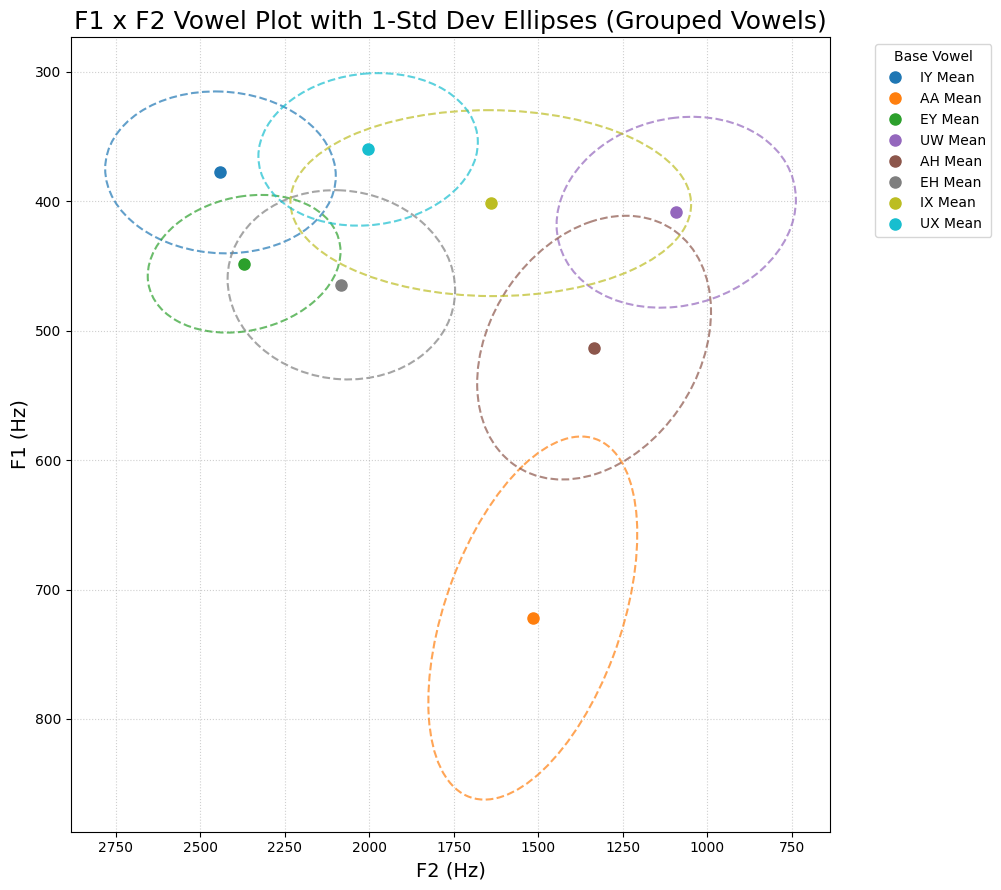

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.cm as cm # For color mapping
import re # Regular expression library for stripping numbers

# --- Start of placeholder for filtered_df if running standalone ---
# In your Google Colab notebook, 'filtered_df' should already exist from the previous steps.
# This block is just for demonstration if you run this code snippet independently.
if 'filtered_df' not in locals():
    print("Warning: 'filtered_df' not found. Creating dummy data for demonstration.")
    np.random.seed(42) # for reproducibility
    data = {
        'F1': np.random.normal(500, 50, 50).tolist() + np.random.normal(520, 45, 50).tolist() + # AA1, AA0
              np.random.normal(700, 60, 50).tolist() + np.random.normal(710, 55, 50).tolist() + # IY1, IY0
              np.random.normal(300, 40, 50).tolist() + np.random.normal(310, 35, 50).tolist() + # UW1, UW0
              np.random.normal(450, 45, 50).tolist() + np.random.normal(460, 40, 50).tolist(),  # AE1, AE0
        'F2': np.random.normal(1500, 100, 50).tolist() + np.random.normal(1550, 90, 50).tolist() +
              np.random.normal(1200, 80, 50).tolist() + np.random.normal(1250, 75, 50).tolist() +
              np.random.normal(2000, 120, 50).tolist() + np.random.normal(2050, 110, 50).tolist() +
              np.random.normal(1800, 90, 50).tolist() + np.random.normal(1850, 85, 50).tolist(),
        'label': ['AA1']*50 + ['AA0']*50 + ['IY1']*50 + ['IY0']*50 +
                 ['UW1']*50 + ['UW0']*50 + ['AE1']*50 + ['AE0']*50,
        'dur': np.random.rand(400), 'intensity': np.random.rand(400), 'f0': np.random.rand(400)
    }
    filtered_df = pd.DataFrame(data)
    filtered_df['F1'] = pd.to_numeric(filtered_df['F1'])
    filtered_df['F2'] = pd.to_numeric(filtered_df['F2'])
# --- End of placeholder ---


# --- New step: Create 'base_vowel' column ---
# This uses a regular expression to remove any trailing digits from the 'label'
filtered_df['base_vowel'] = filtered_df['label'].apply(lambda x: re.sub(r'[0-9]', '', x))

# Group by 'base_vowel' to calculate mean and covariance for F1 and F2
vowel_means = filtered_df.groupby('base_vowel')[['F1', 'F2']].mean()

# Dictionary to store covariance matrices for each base vowel
vowel_covariances = {}
for base_vowel_label in filtered_df['base_vowel'].unique():
    subset = filtered_df[filtered_df['base_vowel'] == base_vowel_label][['F1', 'F2']]
    # Ensure there's enough data for covariance calculation (at least 2 points)
    if len(subset) > 1:
        vowel_covariances[base_vowel_label] = np.cov(subset['F1'], subset['F2'])
    else:
        print(f"Warning: Not enough data for '{base_vowel_label}' to calculate covariance matrix. Skipping ellipse.")
        vowel_covariances[base_vowel_label] = None # Store None to skip plotting ellipse

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 9))

# Get a color map for distinct colors for each base vowel
base_labels = filtered_df['base_vowel'].unique()
colors = cm.get_cmap('tab10', len(base_labels)) # 'tab10' is a good categorical colormap

# Plot each base vowel's mean and 1-standard deviation ellipse
for i, base_vowel_label in enumerate(base_labels):
    mean_f1 = vowel_means.loc[base_vowel_label, 'F1']
    mean_f2 = vowel_means.loc[base_vowel_label, 'F2']
    color = colors(i)

    # Plot the mean point
    ax.plot(mean_f2, mean_f1, 'o', color=color, markersize=8, label=f'{base_vowel_label} Mean', zorder=5)

    # Plot ellipse only if covariance matrix was successfully calculated
    cov_matrix = vowel_covariances.get(base_vowel_label)
    if cov_matrix is not None:
        # Calculate ellipse parameters from the covariance matrix
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Sort eigenvalues in descending order and get corresponding eigenvectors
        order = eigenvalues.argsort()[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]

        # The angle of the ellipse is the angle of the eigenvector corresponding to the largest eigenvalue
        angle = np.degrees(np.arctan2(*eigenvectors[:, 0]))

        # For a "1 standard deviation" ellipse, the half-axes are proportional to sqrt(eigenvalues).
        width, height = 2 * np.sqrt(eigenvalues)

        # Create and add the ellipse patch
        ellipse = Ellipse((mean_f2, mean_f1), width=width, height=height,
                          angle=angle, facecolor='none', edgecolor=color,
                          linestyle='--', linewidth=1.5, alpha=0.7, zorder=3)
        ax.add_patch(ellipse)
    else:
        print(f"Skipping ellipse for '{base_vowel_label}' due to insufficient data for covariance calculation.")


# Customize the plot
ax.set_title('F1 x F2 Vowel Plot with 1-Std Dev Ellipses (Grouped Vowels)', fontsize=18)
ax.set_xlabel('F2 (Hz)', fontsize=14)
ax.set_ylabel('F1 (Hz)', fontsize=14)
ax.invert_yaxis() # F1 is traditionally inverted in phonetic plots
ax.invert_xaxis() # F2 is traditionally inverted in phonetic plots
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(title='Base Vowel', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10) # Place legend outside
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
plt.show()

Bar plot of vowel durations

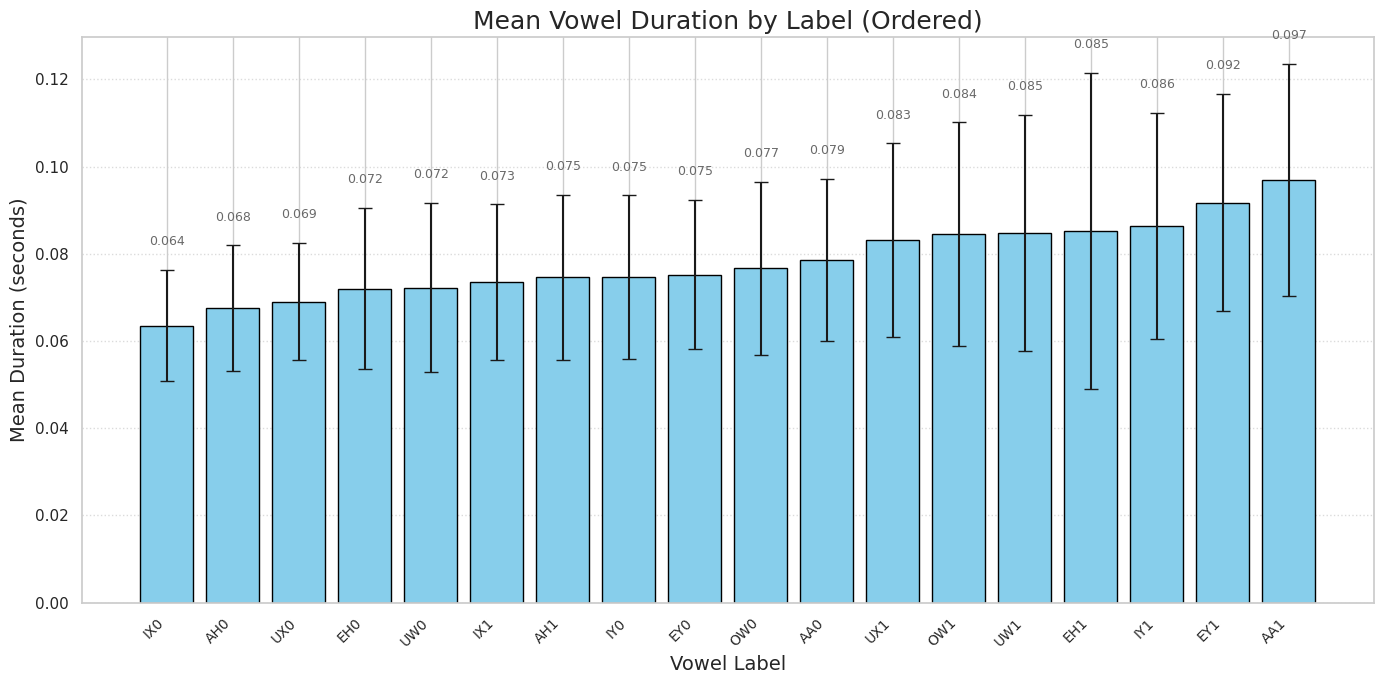

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# --- Start of placeholder for filtered_df if running standalone ---
if 'filtered_df' not in locals():
    print("Warning: 'filtered_df' not found. Creating dummy data for demonstration.")
    np.random.seed(42) # for reproducibility
    data = {
        'F1': np.random.normal(500, 50, 50).tolist() + np.random.normal(520, 45, 50).tolist() +
              np.random.normal(700, 60, 50).tolist() + np.random.normal(710, 55, 50).tolist() +
              np.random.normal(300, 40, 50).tolist() + np.random.normal(310, 35, 50).tolist() +
              np.random.normal(450, 45, 50).tolist() + np.random.normal(460, 40, 50).tolist(),
        'F2': np.random.normal(1500, 100, 50).tolist() + np.random.normal(1550, 90, 50).tolist() +
              np.random.normal(1200, 80, 50).tolist() + np.random.normal(1250, 75, 50).tolist() +
              np.random.normal(2000, 120, 50).tolist() + np.random.normal(2050, 110, 50).tolist() +
              np.random.normal(1800, 90, 50).tolist() + np.random.normal(1850, 85, 50).tolist(),
        'label': ['AA1']*50 + ['AA0']*50 + ['IY1']*50 + ['IY0']*50 +
                 ['UW1']*50 + ['UW0']*50 + ['AE1']*50 + ['AE0']*50,
        'dur': np.random.uniform(0.05, 0.3, 400), # Realistic durations
        'intensity': np.random.rand(400), 'f0': np.random.rand(400)
    }
    filtered_df = pd.DataFrame(data)
    filtered_df['F1'] = pd.to_numeric(filtered_df['F1'])
    filtered_df['F2'] = pd.to_numeric(filtered_df['F2'])
    filtered_df['dur'] = pd.to_numeric(filtered_df['dur'])
# --- End of placeholder ---

# Calculate mean and standard deviation of duration for each 'label'
duration_stats = filtered_df.groupby('label')['dur'].agg(['mean', 'std']).sort_values('mean').reset_index()

# Set up the plot
fig, ax = plt.subplots(figsize=(14, 7)) # Adjust figure size for better readability

# Create the bar plot
bars = ax.bar(duration_stats['label'], duration_stats['mean'],
              yerr=duration_stats['std'], capsize=5, color='skyblue', edgecolor='black')

# Customize the plot
ax.set_title('Mean Vowel Duration by Label (Ordered)', fontsize=18)
ax.set_xlabel('Vowel Label', fontsize=14)
ax.set_ylabel('Mean Duration (seconds)', fontsize=14)

ax.tick_params(axis='x', labelrotation=45, labelsize=10) # Rotate x-axis labels
plt.setp(ax.get_xticklabels(), ha='right')

ax.grid(axis='y', linestyle=':', alpha=0.7) # Add horizontal grid lines

# Optional: Add duration values on top of the bars for precise reading
# Iterate through bars AND the duration_stats DataFrame to get std values
for i, bar in enumerate(bars):
    yval = bar.get_height()
    # Get the standard deviation directly from the duration_stats DataFrame for the current bar's index
    yerr_val = duration_stats['std'].iloc[i] if pd.notna(duration_stats['std'].iloc[i]) else 0

    # Position text above bar + error, making sure it doesn't overlap the error bar cap
    ax.text(bar.get_x() + bar.get_width()/2, yval + yerr_val + 0.005,
            f"{yval:.3f}", ha='center', va='bottom', fontsize=9, color='dimgray') # Corrected color

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

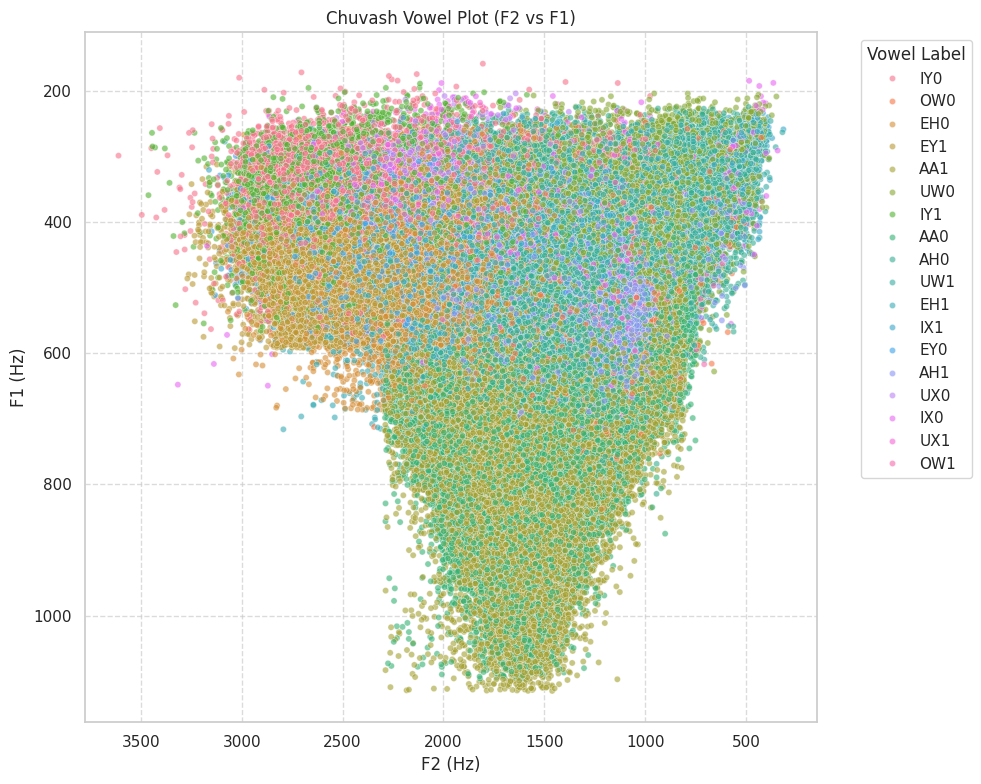

In [ ]:
# Cell 1: Basic Vowel Plot (F2 vs F1)
if not filtered_df.empty:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=filtered_df, x='F2', y='F1', hue='label', alpha=0.6, s=20)
    plt.gca().invert_xaxis() # Invert F2 axis as is common in phonetics
    plt.gca().invert_yaxis() # Invert F1 axis as is common in phonetics
    plt.title('Chuvash Vowel Plot (F2 vs F1)')
    plt.xlabel('F2 (Hz)')
    plt.ylabel('F1 (Hz)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Vowel Label', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No vowel data available for F1/F2 plot.")

/tmp/ipython-input-1296570587.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=filtered_df, x='label', y='F1', inner='quartile', palette='viridis')


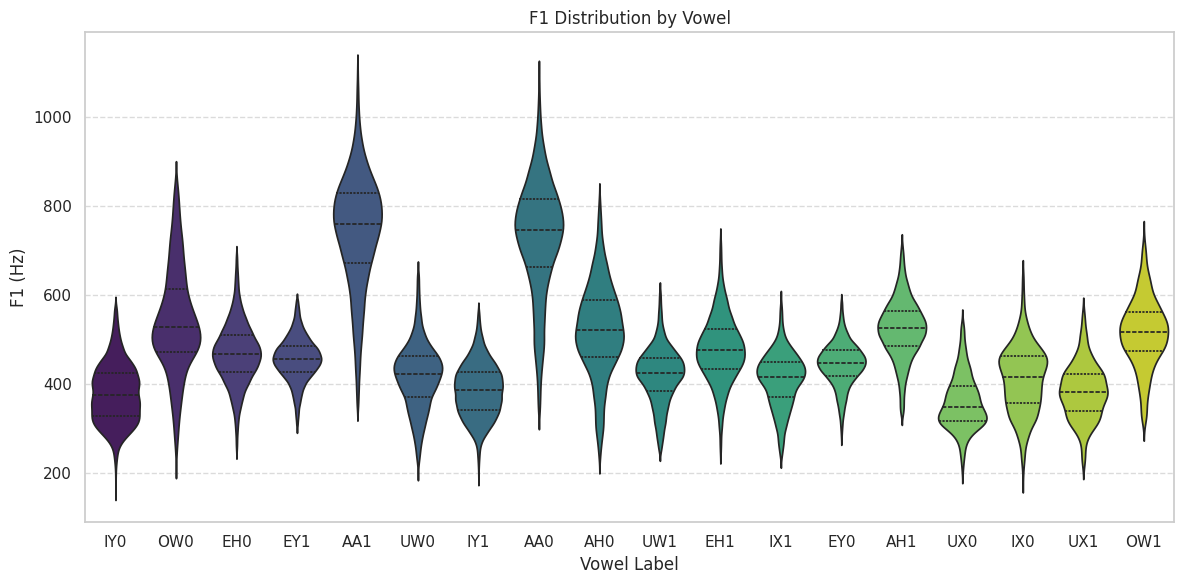

In [ ]:
# Cell 2: F1 Distribution by Vowel
if not filtered_df.empty:
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=filtered_df, x='label', y='F1', inner='quartile', palette='viridis')
    plt.title('F1 Distribution by Vowel')
    plt.xlabel('Vowel Label')
    plt.ylabel('F1 (Hz)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No vowel data available for F1 distribution plot.")

/tmp/ipython-input-2083804386.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_df, x='label', y='dur', palette='plasma')


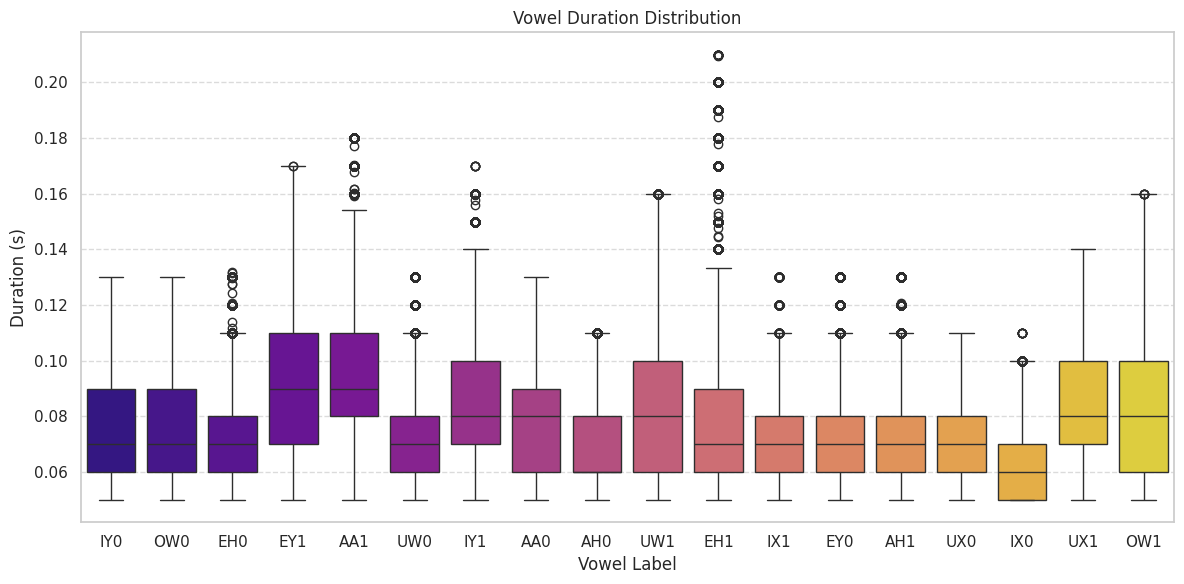

In [ ]:
# Cell 3: Duration Distribution by Vowel
if not filtered_df.empty:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=filtered_df, x='label', y='dur', palette='plasma')
    plt.title('Vowel Duration Distribution')
    plt.xlabel('Vowel Label')
    plt.ylabel('Duration (s)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No vowel data available for duration plot.")

/tmp/ipython-input-2095732963.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=vowels_df_filtered, x='label', y='dur', palette='viridis', order=ordered_vowels)


ANOVA F-statistic: 4584.33, p-value: 0.000

ANOVA results indicate significant differences between vowel groups (p < 0.05).
Performing Tukey HSD post-hoc test for pairwise comparisons:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   AA0    AA1   0.0157    0.0  0.0153  0.0161   True
   AA0    AH0   -0.011    0.0 -0.0116 -0.0105   True
   AA0    AH1   -0.004    0.0 -0.0047 -0.0033   True
   AA0    EH0  -0.0066    0.0 -0.0071  -0.006   True
   AA0    EH1  -0.0018    0.0 -0.0025 -0.0011   True
   AA0    EY0  -0.0034    0.0  -0.004 -0.0027   True
   AA0    EY1   0.0121    0.0  0.0117  0.0126   True
   AA0    IX0  -0.0151    0.0 -0.0163 -0.0138   True
   AA0    IX1  -0.0051    0.0 -0.0062  -0.004   True
   AA0    IY0   -0.004    0.0 -0.0047 -0.0033   True
   AA0    IY1   0.0067    0.0  0.0061  0.0074   True
   AA0    OW0  -0.0019 0.0002 -0.0032 -0.0005   True
   AA0    OW1   0.00

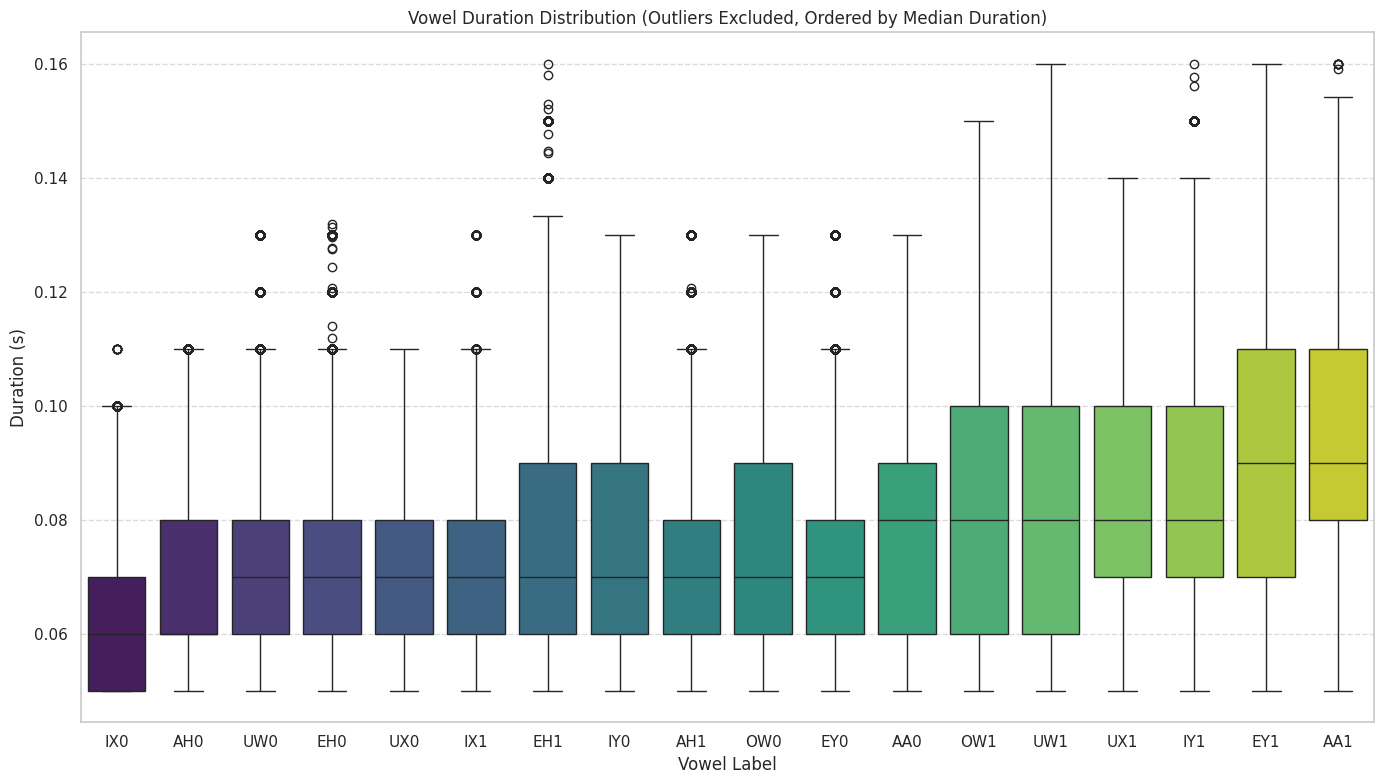

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For f_oneway (ANOVA)
from statsmodels.stats.multicomp import pairwise_tukeyhsd # For Tukey HSD
import pandas as pd # Ensure pandas is imported if not already

# --- START: Dummy vowels_df creation for demonstration ---
# This block is for demonstration purposes. In your actual Jupyter Notebook,
# 'vowels_df' should already be populated from your data processing.
try:
    # Attempt to access vowels_df to see if it exists
    _ = filtered_df.head()
except NameError:
    print("Dummy 'vowels_df' created for demonstration. In actual use, ensure your 'vowels_df' is loaded.")
    data = {
        'label': np.random.choice(['a', 'e', 'i', 'o', 'u', 'ɪ', 'ɛ'], size=1000),
        'dur': np.random.normal(loc=0.15, scale=0.05, size=1000) # Base durations
    }
    # Add some outliers and variations for testing
    data['dur'][::10] = np.random.uniform(0.5, 1.0, size=100) # Longer outliers
    data['dur'][data['label'] == 'a'] += 0.03 # Make 'a' slightly longer on average
    data['dur'][data['label'] == 'i'] -= 0.02 # Make 'i' slightly shorter on average
    vowels_df = pd.DataFrame(data)
# --- END: Dummy vowels_df creation ---


if not filtered_df.empty:
    # 1. Outlier Filtering using IQR (from previous response)
    Q1 = filtered_df['dur'].quantile(0.25)
    Q3 = filtered_df['dur'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out data points outside the outlier bounds
    vowels_df_filtered = filtered_df[(filtered_df['dur'] >= lower_bound) & (filtered_df['dur'] <= upper_bound)]

    # 2. Arrange vowels from shortest to longest median duration
    # Calculate median duration for each vowel label in the filtered data
    median_durations = vowels_df_filtered.groupby('label')['dur'].median().sort_values()
    ordered_vowels = median_durations.index.tolist()

    plt.figure(figsize=(14, 8)) # Increased figure size for better readability
    ax = sns.boxplot(data=vowels_df_filtered, x='label', y='dur', palette='viridis', order=ordered_vowels)
    plt.title('Vowel Duration Distribution (Outliers Excluded, Ordered by Median Duration)')
    plt.xlabel('Vowel Label')
    plt.ylabel('Duration (s)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 3. Perform statistical tests for significance bars
    # Ensure there are at least two unique vowel labels after filtering to perform comparisons
    if len(ordered_vowels) > 1:
        # Prepare groups for ANOVA: a list of duration arrays for each vowel
        groups_for_anova = [vowels_df_filtered['dur'][vowels_df_filtered['label'] == v] for v in ordered_vowels]
        # Filter out any empty groups that might result from filtering
        groups_for_anova = [g for g in groups_for_anova if not g.empty]

        if len(groups_for_anova) > 1:
            # Perform One-way ANOVA to test for overall significant differences
            f_stat, p_anova = stats.f_oneway(*groups_for_anova)
            print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_anova:.3f}")

            # If ANOVA is significant, proceed with post-hoc Tukey HSD test for pairwise comparisons
            if p_anova < 0.05: # Common significance level
                print("\nANOVA results indicate significant differences between vowel groups (p < 0.05).")
                print("Performing Tukey HSD post-hoc test for pairwise comparisons:")

                # Perform Tukey HSD
                tukey_result = pairwise_tukeyhsd(endog=vowels_df_filtered['dur'],
                                                  groups=vowels_df_filtered['label'],
                                                  alpha=0.05) # Significance level
                print(tukey_result) # Prints a table of pairwise comparisons

                # 4. Add significance bars using the 'statannotations' library
                try:
                    from statannotations.Annotator import Annotator
                    print("\n'statannotations' library found. Drawing significance bars for significant pairwise differences...")

                    comparison_pairs = []
                    p_values_for_annotator = []

                    # Iterate through Tukey HSD results to identify significant pairs
                    rows = tukey_result.summary().data[1:] # Skip header row of the summary table
                    for row_data in rows:
                        group1, group2, _, _, p_value, reject_null = row_data
                        # If the null hypothesis is rejected, this pair is significantly different
                        if reject_null: # 'reject_null' is True if p_value < alpha (0.05 in this case)
                            # Ensure the pair is ordered correctly for statannotations based on 'ordered_vowels'
                            idx1 = ordered_vowels.index(group1)
                            idx2 = ordered_vowels.index(group2)

                            if idx1 < idx2:
                                pair = (group1, group2)
                            else:
                                pair = (group2, group1)

                            comparison_pairs.append(pair)
                            p_values_for_annotator.append(p_value)

                    if comparison_pairs:
                        # Initialize Annotator with the axis, comparison pairs, data, and column names
                        annotator = Annotator(ax, comparison_pairs, data=vowels_df_filtered,
                                              x='label', y='dur', order=ordered_vowels)
                        # Configure to use star notation (*, **, ***) for significance and place bars outside the plot area
                        annotator.configure(test=None, text_format='star', loc='outside')
                        # Pass the pre-calculated p-values to the annotator for drawing
                        annotator.set_pvalues_and_annotate(p_values=p_values_for_annotator)
                    else:
                        print("No significant pairwise differences (p < 0.05) found to annotate on the plot.")

                except ImportError:
                    print("\n'statannotations' library not found. To draw significance bars on the plot, please install it:")
                    print("pip install statannotations")
                    print("Proceeding without drawing significance bars on the plot, but Tukey HSD results are printed above.")
            else:
                print("\nANOVA results indicate no significant overall differences between vowel groups (p >= 0.05).")
                print("Skipping post-hoc Tukey HSD test and significance bar drawing.")
        else:
            print("Not enough non-empty vowel groups in the filtered data to perform ANOVA and statistical comparisons.")
    else:
        print("Not enough unique vowel labels in the filtered data to perform statistical comparisons.")

    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("No vowel data available for duration plot.")

/tmp/ipython-input-3119186733.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=vowels_df_filtered, x='label', y='intensity', palette='viridis', order=ordered_vowels)


ANOVA F-statistic: 981.34, p-value: 0.000

ANOVA results indicate significant differences between vowel groups (p < 0.05).
Performing Tukey HSD post-hoc test for pairwise comparisons:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   AA0    AA1  -0.2315    0.0 -0.3207 -0.1423   True
   AA0    AH0  -1.8092    0.0 -1.9247 -1.6937   True
   AA0    AH1  -0.7712    0.0 -0.9327 -0.6097   True
   AA0    EH0  -1.8378    0.0 -1.9564 -1.7191   True
   AA0    EH1   -2.565    0.0 -2.7115 -2.4186   True
   AA0    EY0  -0.7016    0.0 -0.8385 -0.5647   True
   AA0    EY1  -0.5233    0.0 -0.6189 -0.4276   True
   AA0    IX0   -2.028    0.0 -2.2904 -1.7655   True
   AA0    IX1  -1.8354    0.0 -2.0903 -1.5806   True
   AA0    IY0  -2.7372    0.0 -2.8818 -2.5925   True
   AA0    IY1  -2.0393    0.0 -2.1724 -1.9062   True
   AA0    OW0  -0.6087    0.0 -0.8485  -0.369   True
   AA0    OW1   0.432

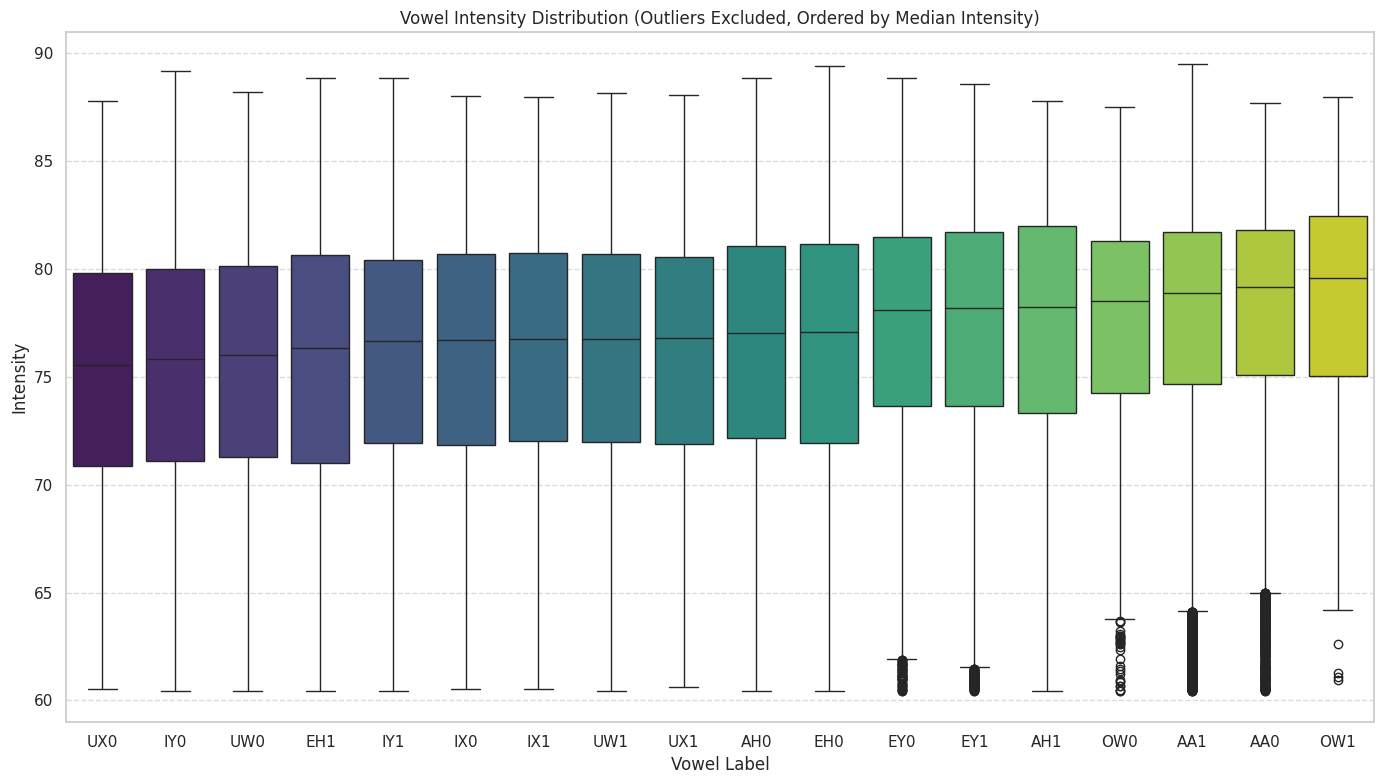

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For f_oneway (ANOVA)
from statsmodels.stats.multicomp import pairwise_tukeyhsd # For Tukey HSD
import pandas as pd # Ensure pandas is imported if not already

# --- START: Dummy vowels_df creation for demonstration ---
# This block is for demonstration purposes. In your actual Jupyter Notebook,
# 'vowels_df' should already be populated from your data processing.
try:
    # Attempt to access vowels_df to see if it exists
    _ = vowels_df.head()
except NameError:
    print("Dummy 'vowels_df' created for demonstration. In actual use, ensure your 'vowels_df' is loaded.")
    data = {
        'label': np.random.choice(['a', 'e', 'i', 'o', 'u', 'ɪ', 'ɛ'], size=1000),
        'intensity': np.random.normal(loc=0.15, scale=0.05, size=1000) # Base durations
    }
    # Add some outliers and variations for testing
    data['intensity'][::10] = np.random.uniform(0.5, 1.0, size=100) # Longer outliers
    data['intensity'][data['label'] == 'a'] += 0.03 # Make 'a' slightly longer on average
    data['intensity'][data['label'] == 'i'] -= 0.02 # Make 'i' slightly shorter on average
    vowels_df = pd.DataFrame(data)
# --- END: Dummy vowels_df creation ---


if not vowels_df.empty:
    # 1. Outlier Filtering using IQR (from previous response)
    Q1 = vowels_df['intensity'].quantile(0.25)
    Q3 = vowels_df['intensity'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out data points outside the outlier bounds
    vowels_df_filtered = vowels_df[(vowels_df['intensity'] >= lower_bound) & (vowels_df['intensity'] <= upper_bound)]

    # 2. Arrange vowels from shortest to longest median duration
    # Calculate median duration for each vowel label in the filtered data
    median_durations = vowels_df_filtered.groupby('label')['intensity'].median().sort_values()
    ordered_vowels = median_durations.index.tolist()

    plt.figure(figsize=(14, 8)) # Increased figure size for better readability
    ax = sns.boxplot(data=vowels_df_filtered, x='label', y='intensity', palette='viridis', order=ordered_vowels)
    plt.title('Vowel Intensity Distribution (Outliers Excluded, Ordered by Median Intensity)')
    plt.xlabel('Vowel Label')
    plt.ylabel('Intensity')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 3. Perform statistical tests for significance bars
    # Ensure there are at least two unique vowel labels after filtering to perform comparisons
    if len(ordered_vowels) > 1:
        # Prepare groups for ANOVA: a list of duration arrays for each vowel
        groups_for_anova = [vowels_df_filtered['intensity'][vowels_df_filtered['label'] == v] for v in ordered_vowels]
        # Filter out any empty groups that might result from filtering
        groups_for_anova = [g for g in groups_for_anova if not g.empty]

        if len(groups_for_anova) > 1:
            # Perform One-way ANOVA to test for overall significant differences
            f_stat, p_anova = stats.f_oneway(*groups_for_anova)
            print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_anova:.3f}")

            # If ANOVA is significant, proceed with post-hoc Tukey HSD test for pairwise comparisons
            if p_anova < 0.05: # Common significance level
                print("\nANOVA results indicate significant differences between vowel groups (p < 0.05).")
                print("Performing Tukey HSD post-hoc test for pairwise comparisons:")

                # Perform Tukey HSD
                tukey_result = pairwise_tukeyhsd(endog=vowels_df_filtered['intensity'],
                                                  groups=vowels_df_filtered['label'],
                                                  alpha=0.05) # Significance level
                print(tukey_result) # Prints a table of pairwise comparisons

                # 4. Add significance bars using the 'statannotations' library
                try:
                    from statannotations.Annotator import Annotator
                    print("\n'statannotations' library found. Drawing significance bars for significant pairwise differences...")

                    comparison_pairs = []
                    p_values_for_annotator = []

                    # Iterate through Tukey HSD results to identify significant pairs
                    rows = tukey_result.summary().data[1:] # Skip header row of the summary table
                    for row_data in rows:
                        group1, group2, _, _, p_value, reject_null = row_data
                        # If the null hypothesis is rejected, this pair is significantly different
                        if reject_null: # 'reject_null' is True if p_value < alpha (0.05 in this case)
                            # Ensure the pair is ordered correctly for statannotations based on 'ordered_vowels'
                            idx1 = ordered_vowels.index(group1)
                            idx2 = ordered_vowels.index(group2)

                            if idx1 < idx2:
                                pair = (group1, group2)
                            else:
                                pair = (group2, group1)

                            comparison_pairs.append(pair)
                            p_values_for_annotator.append(p_value)

                    if comparison_pairs:
                        # Initialize Annotator with the axis, comparison pairs, data, and column names
                        annotator = Annotator(ax, comparison_pairs, data=vowels_df_filtered,
                                              x='label', y='intensity', order=ordered_vowels)
                        # Configure to use star notation (*, **, ***) for significance and place bars outside the plot area
                        annotator.configure(test=None, text_format='star', loc='outside')
                        # Pass the pre-calculated p-values to the annotator for drawing
                        annotator.set_pvalues_and_annotate(p_values=p_values_for_annotator)
                    else:
                        print("No significant pairwise differences (p < 0.05) found to annotate on the plot.")

                except ImportError:
                    print("\n'statannotations' library not found. To draw significance bars on the plot, please install it:")
                    print("pip install statannotations")
                    print("Proceeding without drawing significance bars on the plot, but Tukey HSD results are printed above.")
            else:
                print("\nANOVA results indicate no significant overall differences between vowel groups (p >= 0.05).")
                print("Skipping post-hoc Tukey HSD test and significance bar drawing.")
        else:
            print("Not enough non-empty vowel groups in the filtered data to perform ANOVA and statistical comparisons.")
    else:
        print("Not enough unique vowel labels in the filtered data to perform statistical comparisons.")

    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("No vowel data available for duration plot.")

/tmp/ipython-input-1678497727.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=vowels_df_filtered, x='label', y='f0', palette='viridis', order=ordered_vowels)


ANOVA F-statistic: 286.38, p-value: 0.000

ANOVA results indicate significant differences between vowel groups (p < 0.05).
Performing Tukey HSD post-hoc test for pairwise comparisons:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
   AA0    AA1  -2.5145    0.0   -3.215  -1.814   True
   AA0    AH0   1.2427 0.0003   0.3354  2.1499   True
   AA0    AH1   5.6512    0.0   4.3883   6.914   True
   AA0    EH0  -0.3309  0.999  -1.2635  0.6017  False
   AA0    EH1   -3.956    0.0  -5.1006 -2.8115   True
   AA0    EY0   1.7903    0.0   0.7122  2.8684   True
   AA0    EY1   2.9841    0.0   2.2348  3.7334   True
   AA0    IX0   8.6822    0.0   6.6102 10.7542   True
   AA0    IX1  10.5148    0.0   8.5182 12.5113   True
   AA0    IY0   3.6966    0.0    2.564  4.8291   True
   AA0    IY1    9.684    0.0   8.6439 10.7241   True
   AA0    OW0  -0.4606    1.0  -2.3472   1.426  False
   AA0

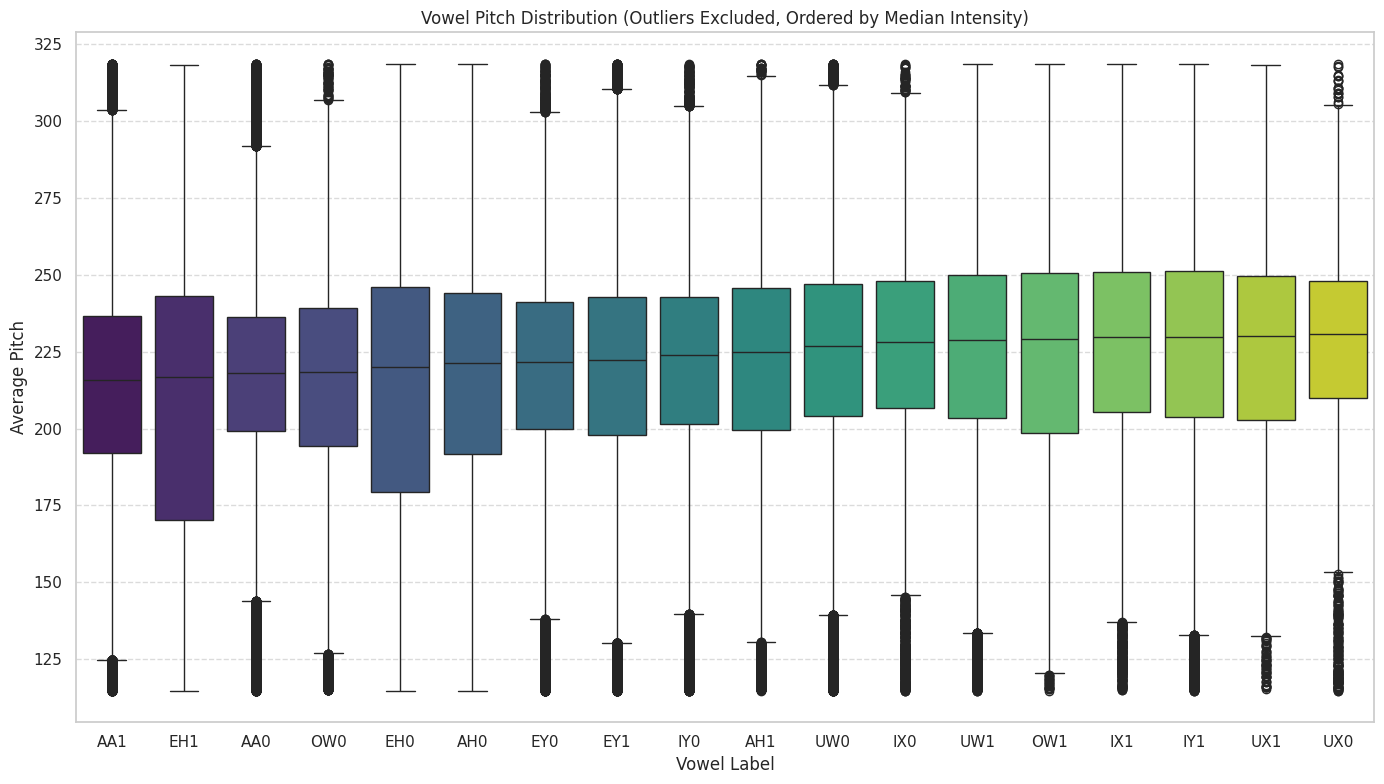

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For f_oneway (ANOVA)
from statsmodels.stats.multicomp import pairwise_tukeyhsd # For Tukey HSD
import pandas as pd # Ensure pandas is imported if not already

# --- START: Dummy vowels_df creation for demonstration ---
# This block is for demonstration purposes. In your actual Jupyter Notebook,
# 'vowels_df' should already be populated from your data processing.
try:
    # Attempt to access vowels_df to see if it exists
    _ = vowels_df.head()
except NameError:
    print("Dummy 'vowels_df' created for demonstration. In actual use, ensure your 'vowels_df' is loaded.")
    data = {
        'label': np.random.choice(['a', 'e', 'i', 'o', 'u', 'ɪ', 'ɛ'], size=1000),
        'f0': np.random.normal(loc=0.15, scale=0.05, size=1000) # Base durations
    }
    # Add some outliers and variations for testing
    data['f0'][::10] = np.random.uniform(0.5, 1.0, size=100) # Longer outliers
    data['f0'][data['label'] == 'a'] += 0.03 # Make 'a' slightly longer on average
    data['f0'][data['label'] == 'i'] -= 0.02 # Make 'i' slightly shorter on average
    vowels_df = pd.DataFrame(data)
# --- END: Dummy vowels_df creation ---


if not vowels_df.empty:
    # 1. Outlier Filtering using IQR (from previous response)
    Q1 = vowels_df['f0'].quantile(0.25)
    Q3 = vowels_df['f0'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out data points outside the outlier bounds
    vowels_df_filtered = vowels_df[(vowels_df['f0'] >= lower_bound) & (vowels_df['f0'] <= upper_bound)]

    # 2. Arrange vowels from shortest to longest median duration
    # Calculate median duration for each vowel label in the filtered data
    median_durations = vowels_df_filtered.groupby('label')['f0'].median().sort_values()
    ordered_vowels = median_durations.index.tolist()

    plt.figure(figsize=(14, 8)) # Increased figure size for better readability
    ax = sns.boxplot(data=vowels_df_filtered, x='label', y='f0', palette='viridis', order=ordered_vowels)
    plt.title('Vowel Pitch Distribution (Outliers Excluded, Ordered by Median Intensity)')
    plt.xlabel('Vowel Label')
    plt.ylabel('Average Pitch')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 3. Perform statistical tests for significance bars
    # Ensure there are at least two unique vowel labels after filtering to perform comparisons
    if len(ordered_vowels) > 1:
        # Prepare groups for ANOVA: a list of duration arrays for each vowel
        groups_for_anova = [vowels_df_filtered['f0'][vowels_df_filtered['label'] == v] for v in ordered_vowels]
        # Filter out any empty groups that might result from filtering
        groups_for_anova = [g for g in groups_for_anova if not g.empty]

        if len(groups_for_anova) > 1:
            # Perform One-way ANOVA to test for overall significant differences
            f_stat, p_anova = stats.f_oneway(*groups_for_anova)
            print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_anova:.3f}")

            # If ANOVA is significant, proceed with post-hoc Tukey HSD test for pairwise comparisons
            if p_anova < 0.05: # Common significance level
                print("\nANOVA results indicate significant differences between vowel groups (p < 0.05).")
                print("Performing Tukey HSD post-hoc test for pairwise comparisons:")

                # Perform Tukey HSD
                tukey_result = pairwise_tukeyhsd(endog=vowels_df_filtered['f0'],
                                                  groups=vowels_df_filtered['label'],
                                                  alpha=0.05) # Significance level
                print(tukey_result) # Prints a table of pairwise comparisons

                # 4. Add significance bars using the 'statannotations' library
                try:
                    from statannotations.Annotator import Annotator
                    print("\n'statannotations' library found. Drawing significance bars for significant pairwise differences...")

                    comparison_pairs = []
                    p_values_for_annotator = []

                    # Iterate through Tukey HSD results to identify significant pairs
                    rows = tukey_result.summary().data[1:] # Skip header row of the summary table
                    for row_data in rows:
                        group1, group2, _, _, p_value, reject_null = row_data
                        # If the null hypothesis is rejected, this pair is significantly different
                        if reject_null: # 'reject_null' is True if p_value < alpha (0.05 in this case)
                            # Ensure the pair is ordered correctly for statannotations based on 'ordered_vowels'
                            idx1 = ordered_vowels.index(group1)
                            idx2 = ordered_vowels.index(group2)

                            if idx1 < idx2:
                                pair = (group1, group2)
                            else:
                                pair = (group2, group1)

                            comparison_pairs.append(pair)
                            p_values_for_annotator.append(p_value)

                    if comparison_pairs:
                        # Initialize Annotator with the axis, comparison pairs, data, and column names
                        annotator = Annotator(ax, comparison_pairs, data=vowels_df_filtered,
                                              x='label', y='f0', order=ordered_vowels)
                        # Configure to use star notation (*, **, ***) for significance and place bars outside the plot area
                        annotator.configure(test=None, text_format='star', loc='outside')
                        # Pass the pre-calculated p-values to the annotator for drawing
                        annotator.set_pvalues_and_annotate(p_values=p_values_for_annotator)
                    else:
                        print("No significant pairwise differences (p < 0.05) found to annotate on the plot.")

                except ImportError:
                    print("\n'statannotations' library not found. To draw significance bars on the plot, please install it:")
                    print("pip install statannotations")
                    print("Proceeding without drawing significance bars on the plot, but Tukey HSD results are printed above.")
            else:
                print("\nANOVA results indicate no significant overall differences between vowel groups (p >= 0.05).")
                print("Skipping post-hoc Tukey HSD test and significance bar drawing.")
        else:
            print("Not enough non-empty vowel groups in the filtered data to perform ANOVA and statistical comparisons.")
    else:
        print("Not enough unique vowel labels in the filtered data to perform statistical comparisons.")

    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("No vowel data available for duration plot.")

Stress comparison

Stress Category Distribution:
stress_category
Rightmost Strong Stress (RSS)    196697
Non-Initial Unstressed (NIUS)     80336
Leftmost Weak Stress (LWS)        22155
Initial Unstressed (IUS)          17192
Name: count, dtype: int64


/tmp/ipython-input-1983290245.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_category', y=feature, data=data, palette='viridis')


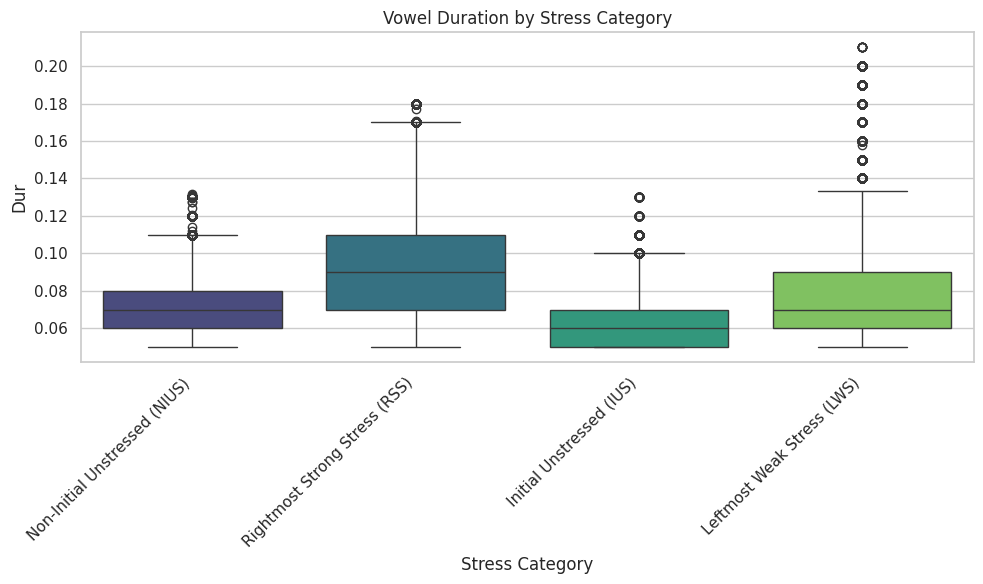

/tmp/ipython-input-1983290245.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_category', y=feature, data=data, palette='viridis')


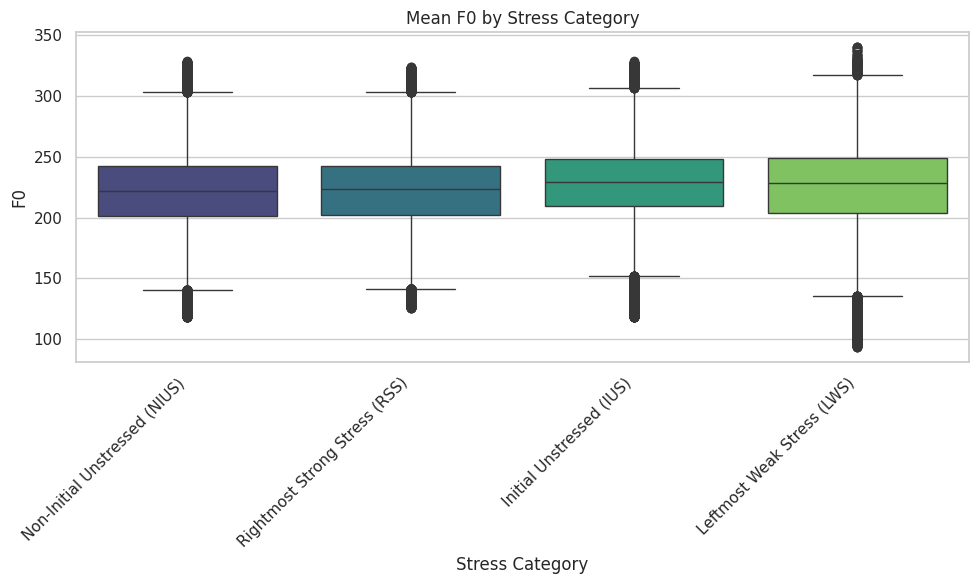

/tmp/ipython-input-1983290245.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_category', y=feature, data=data, palette='viridis')


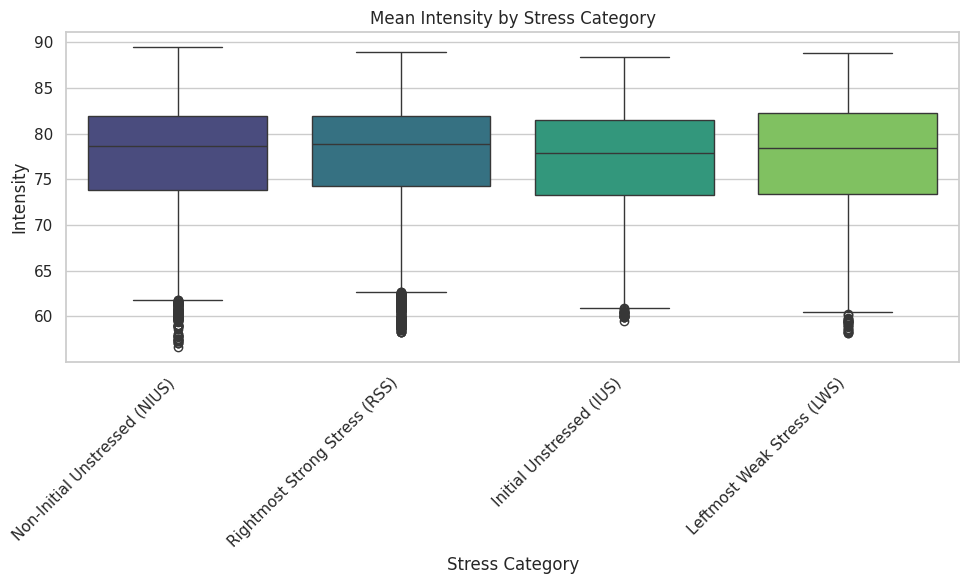

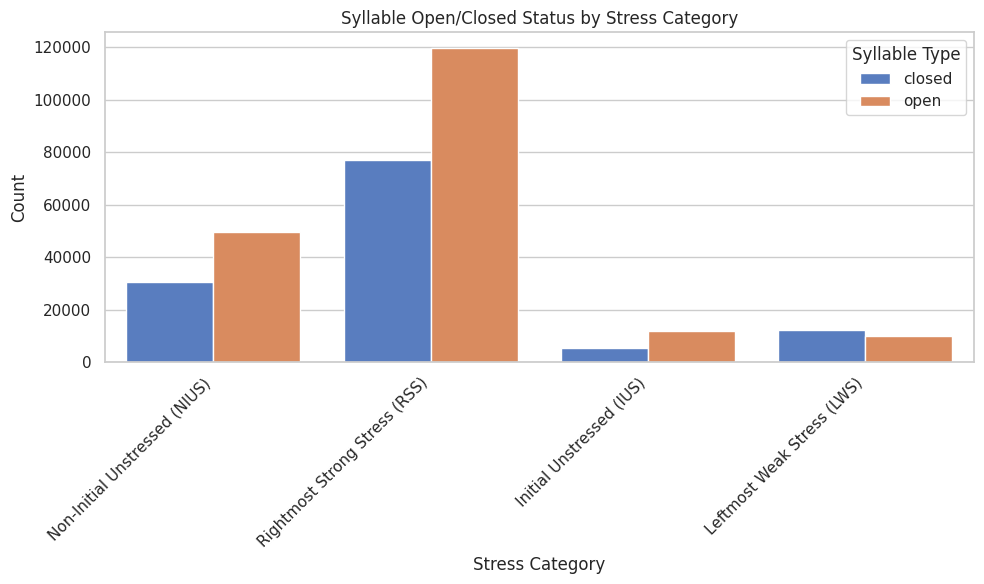

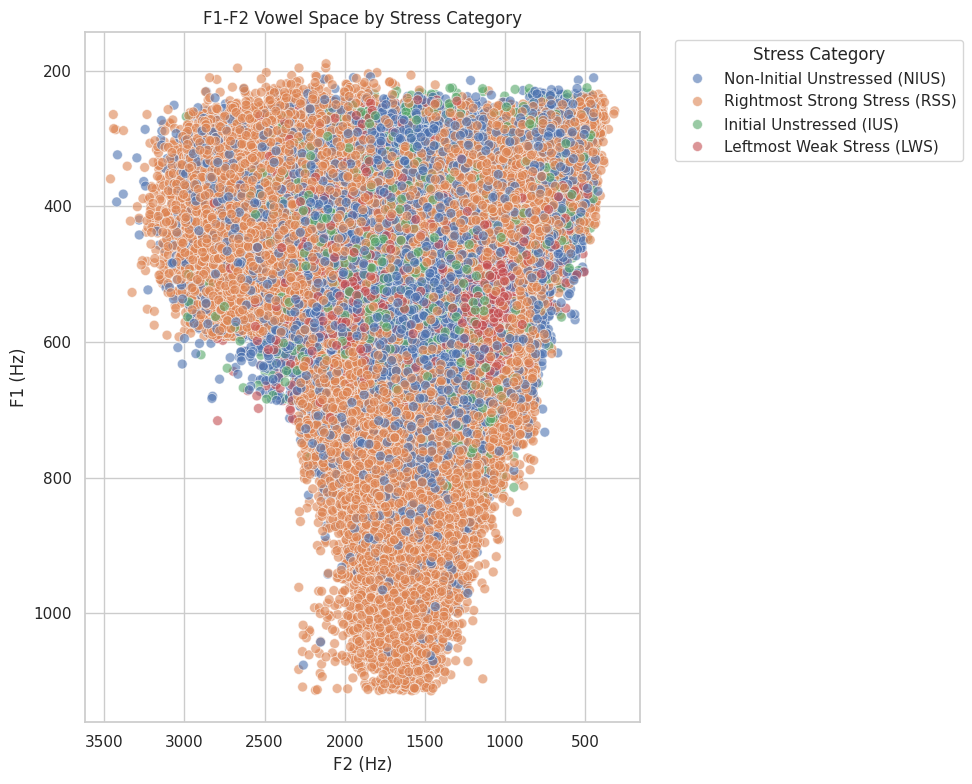


--- Statistical Analysis ---
LWS vs RSS - Duration: t=-68.06, p=0.000

Linear Model (OLS) for Duration:
                            OLS Regression Results                            
Dep. Variable:                    dur   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                 1.592e+04
Date:                Mon, 05 Jan 2026   Prob (F-statistic):               0.00
Time:                        19:53:34   Log-Likelihood:             7.3082e+05
No. Observations:              316380   AIC:                        -1.462e+06
Df Residuals:                  316376   BIC:                        -1.462e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.0

/tmp/ipython-input-1983290245.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_category', y=feature, data=data, palette='viridis')


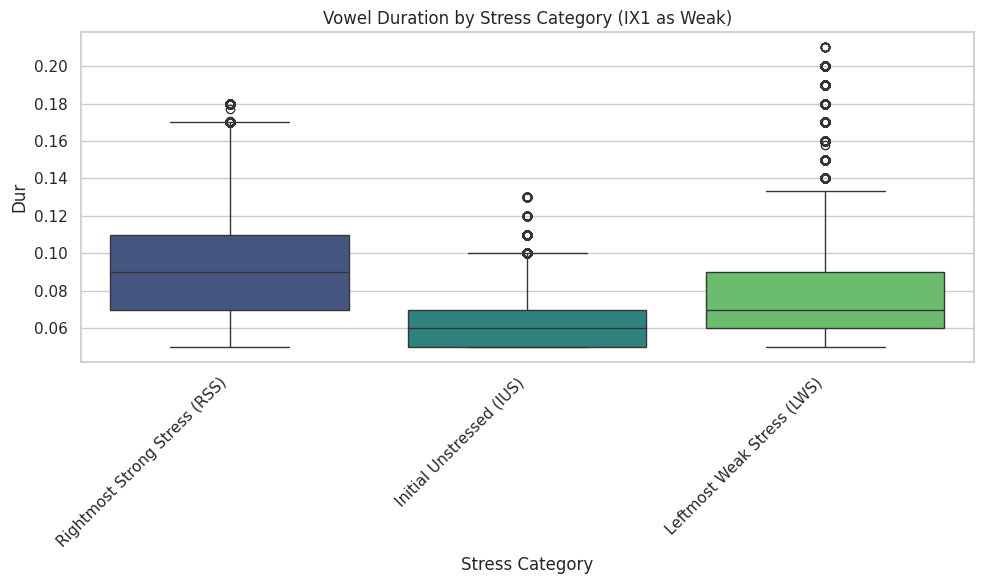

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf # For linear models

# Assuming your dataframe is already loaded, e.g., from a CSV or pickle file
df = filtered_df
# Or create a dummy dataframe for demonstration

# --- 1. Define Stress Categories ---
leftmost_weak_stress_labels = ['AH1', 'EH1']
rightmost_strong_stress_labels = ['AA1', 'EY1', 'IX1', 'IY1', 'OW1', 'UW1', 'UX1'] # IX1 included initially
unstressed_labels = ['AH0', 'EH0', 'AA0', 'EY0', 'IX0', 'IY0', 'OW0', 'UW0', 'UX0']
initial_unstressed_labels = ['AH0', 'EH0']

df['stress_category'] = 'Other' # Default category

# Leftmost Weak Stress (LWS)
df.loc[(df['label'].isin(leftmost_weak_stress_labels)) & (df['syl_pos'] == 'initial'), 'stress_category'] = 'Leftmost Weak Stress (LWS)'

# Rightmost Strong Stress (RSS)
df.loc[df['label'].isin(rightmost_strong_stress_labels), 'stress_category'] = 'Rightmost Strong Stress (RSS)'

# Initial Unstressed (IUS)
df.loc[(df['label'].isin(initial_unstressed_labels)) & (df['syl_pos'] == 'initial'), 'stress_category'] = 'Initial Unstressed (IUS)'

# Non-Initial Unstressed (IUS)
df.loc[(df['label'].isin(unstressed_labels)) & (df['syl_pos'] != 'initial'), 'stress_category'] = 'Non-Initial Unstressed (NIUS)'


# Filter to only the categories of interest for the main analysis
analysis_df = df[df['stress_category'].isin(['Leftmost Weak Stress (LWS)', 'Rightmost Strong Stress (RSS)', 'Initial Unstressed (IUS)', 'Non-Initial Unstressed (NIUS)'])].copy()

print("Stress Category Distribution:")
print(analysis_df['stress_category'].value_counts())

# --- 2. Visualizations ---

# Set a consistent style for plots
sns.set_theme(style="whitegrid")

# Function to create box plots for acoustic features
def plot_acoustic_features(data, feature, title):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='stress_category', y=feature, data=data, palette='viridis')
    plt.title(title)
    plt.xlabel('Stress Category')
    plt.ylabel(feature.replace('_', ' ').capitalize())
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Duration
plot_acoustic_features(analysis_df, 'dur', 'Vowel Duration by Stress Category')

# F0 (Pitch)
plot_acoustic_features(analysis_df, 'f0', 'Mean F0 by Stress Category')

# Intensity
plot_acoustic_features(analysis_df, 'intensity', 'Mean Intensity by Stress Category')

# Vowel Open/Closed (syl_open_closed) comparison
plt.figure(figsize=(10, 6))
sns.countplot(x='stress_category', hue='syl_open_closed', data=analysis_df, palette='muted')
plt.title('Syllable Open/Closed Status by Stress Category')
plt.xlabel('Stress Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Syllable Type')
plt.tight_layout()
plt.show()

# F1-F2 Vowel Space Plot
# It's good practice to normalize F1/F2 if you have many speakers, but for a general plot:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='F2', y='F1', hue='stress_category', data=analysis_df, alpha=0.6, s=50, palette='deep')
plt.gca().invert_xaxis() # F2 typically decreases to the right
plt.gca().invert_yaxis() # F1 typically decreases upwards
plt.title('F1-F2 Vowel Space by Stress Category')
plt.xlabel('F2 (Hz)')
plt.ylabel('F1 (Hz)')
plt.legend(title='Stress Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


# --- 3. Statistical Models ---

# Compare Leftmost Weak Stress (LWS) vs Rightmost Strong Stress (RSS)
# and LWS vs Initial Unstressed (IUS)

# For 'dur', 'f0', 'intensity' (continuous variables):
# You can use ANOVA if you have more than two groups, or t-tests for pairwise comparisons.
# For more robust analysis, especially with speaker variability, Linear Mixed-Effects Models (LMEMs) are recommended.

print("\n--- Statistical Analysis ---")

# Example using a simple ANOVA (for demonstration; LMEMs are often better for speech data)
# Filter for the relevant comparison groups for duration
comparison_df = analysis_df[analysis_df['stress_category'].isin(['Leftmost Weak Stress (LWS)', 'Rightmost Strong Stress (RSS)'])]

if len(comparison_df['stress_category'].unique()) == 2:
    lws_dur = comparison_df[comparison_df['stress_category'] == 'Leftmost Weak Stress (LWS)']['dur']
    rss_dur = comparison_df[comparison_df['stress_category'] == 'Rightmost Strong Stress (RSS)']['dur']
    if not lws_dur.empty and not rss_dur.empty:
        t_stat, p_val = stats.ttest_ind(lws_dur, rss_dur, equal_var=False) # Welch's t-test assuming unequal variances
        print(f"LWS vs RSS - Duration: t={t_stat:.2f}, p={p_val:.3f}")
    else:
        print("Not enough data for LWS vs RSS duration t-test.")
else:
    print("Cannot perform t-test; groups not correctly filtered or insufficient data.")

# Linear Regression (OLS) example for duration, treating stress_category as a predictor
# This is a basic model, LMEMs are often preferred for repeated measures data.
print("\nLinear Model (OLS) for Duration:")
model_dur = smf.ols('dur ~ C(stress_category)', data=analysis_df).fit()
print(model_dur.summary())

# Similar models can be run for f0 and intensity.
print("\nLinear Model (OLS) for F0:")
model_f0 = smf.ols('f0 ~ C(stress_category)', data=analysis_df).fit()
print(model_f0.summary())

print("\nLinear Model (OLS) for Intensity:")
model_intensity = smf.ols('intensity ~ C(stress_category)', data=analysis_df).fit()
print(model_intensity.summary())

# For 'syl_open_closed' (categorical variable):
# Use Chi-squared test for independence
print("\nChi-squared Test for Syllable Open/Closed Status:")
contingency_table = pd.crosstab(analysis_df['stress_category'], analysis_df['syl_open_closed'])
print(contingency_table)
chi2, p_val, dof, ex = stats.chi2_contingency(contingency_table)
print(f"Chi-squared statistic: {chi2:.2f}, p-value: {p_val:.3f}")


# --- 4. Sub-analysis: IX1 as a weak vowel ---
print("\n--- Sub-analysis: IX1 as a Weak Vowel ---")

# Re-categorize the 'stress_category' column for this sub-analysis
sub_analysis_df = df.copy() # Start with a fresh copy of the original df

# Define new categories for sub-analysis
sub_analysis_df['sub_stress_category'] = 'Other'
sub_analysis_df.loc[(sub_analysis_df['label'].isin(leftmost_weak_stress_labels)) & (sub_analysis_df['syl_pos'] == 'initial'), 'sub_stress_category'] = 'Leftmost Weak Stress (LWS)'
sub_analysis_df.loc[(sub_analysis_df['label'] == 'IX1') & (sub_analysis_df['syl_pos'] == 'initial'), 'sub_stress_category'] = 'Weak Stress (IX1 Initial)' # IX1 considered weak if also initial
# Adjust RSS to exclude IX1
rightmost_strong_stress_labels_no_IX1 = ['AA1', 'EY1', 'IY1', 'OW1', 'UW1', 'UX1']
sub_analysis_df.loc[sub_analysis_df['label'].isin(rightmost_strong_stress_labels_no_IX1), 'sub_stress_category'] = 'Rightmost Strong Stress (RSS_noIX1)'
sub_analysis_df.loc[(sub_analysis_df['label'].isin(initial_unstressed_labels)) & (sub_analysis_df['syl_pos'] == 'initial'), 'sub_stress_category'] = 'Initial Unstressed (IUS)'
sub_analysis_df.loc[(sub_analysis_df['label'].isin(unstressed_labels)) & (sub_analysis_df['syl_pos'] != 'initial'), 'sub_stress_category'] = 'Non-Initial Unstressed (IUS)'


# Filter for the relevant categories for this sub-analysis
sub_analysis_df = sub_analysis_df[sub_analysis_df['sub_stress_category'].isin([
    'Leftmost Weak Stress (LWS)',
    'Weak Stress (IX1 Initial)',
    'Rightmost Strong Stress (RSS_noIX1)',
    'Initial Unstressed (IUS)',
    'Non-Initial Unstressed (NIUS)'
])].copy()

print("Sub-analysis Stress Category Distribution:")
print(sub_analysis_df['sub_stress_category'].value_counts())

# You can now regenerate plots and run statistical models using 'sub_stress_category'
# For example, a box plot for duration in the sub-analysis:
plot_acoustic_features(sub_analysis_df, 'dur', 'Vowel Duration by Stress Category (IX1 as Weak)')

### Explanation of the Code and Approach:

1.  **Data Categorization:**
    *   A new column `stress_category` is created in your DataFrame.
    *   It's populated based on your `label` and `syl_pos` criteria for 'Leftmost Weak Stress (LWS)', 'Rightmost Strong Stress (RSS)', and 'Initial Unstressed (IUS)'.
    *   The `analysis_df` is then created, containing only the rows relevant to these stress categories.

2.  **Visualizations:**
    *   **Box Plots/Violin Plots:** The `plot_acoustic_features` function generates box plots (you could easily switch to `violinplot` for more density information) for `dur`, `f0`, and `intensity`. These plots visually compare the distributions of these acoustic features across your defined stress categories. You would expect to see higher medians and potentially wider ranges for stressed vowels.
    *   **Count Plot for Syllable Open/Closed:** This bar plot shows the distribution of 'O' (open) and 'C' (closed) syllables within each stress category, allowing you to visually assess if stressed vowels are indeed more likely to be closed.
    *   **F1-F2 Vowel Space Plot:** A scatter plot of F1 against F2, with points colored by stress category, helps visualize the acoustic space occupied by each vowel type. Remember to invert the axes as F1 decreases with vowel height and F2 decreases with backness.

3.  **Statistical Models:**
    *   **T-tests/ANOVA:** For continuous variables like `dur`, `f0`, and `intensity`, you can use `scipy.stats.ttest_ind` for pairwise comparisons (e.g., LWS vs. RSS) or perform an ANOVA if comparing three or more groups (e.g., LWS, RSS, IUS). However, basic t-tests and ANOVAs assume independence of observations, which is often violated in speech data due to multiple measurements from the same speaker.
    *   **Linear Regression (OLS):** `statsmodels.formula.api.ols` is demonstrated to model an acoustic feature (e.g., `dur`) as a function of `stress_category`. The `C()` around `stress_category` tells `statsmodels` to treat it as a categorical variable. The summary provides coefficients and p-values, indicating significant differences between the baseline category and others.
    *   **Linear Mixed-Effects Models (LMEMs):** For robust analysis of speech data, especially when you have multiple observations per speaker (`speaker_num`) or per file (`file_name`), LMEMs are highly recommended. Libraries like `statsmodels.api.MixedLM` or external packages like `pymer4` (which wraps R's `lme4` in Python) allow you to account for random effects (e.g., `speaker_num` as a random intercept). This helps control for inter-speaker variability. While the example uses OLS for simplicity, consider exploring LMEMs for your final analysis.
    *   **Chi-squared Test:** For categorical variables like `syl_open_closed`, `scipy.stats.chi2_contingency` can test for independence between `stress_category` and the syllable type.

4.  **Sub-analysis for IX1:**
    *   The code demonstrates how to create a new `sub_stress_category` column, redefining the categories to treat IX1 differently. You would then repeat the relevant plotting and statistical steps using this new column. For example, if IX1 is weak and initial, it could be grouped with AH1/EH1. If it's weak but not necessarily initial, it could form its own 'Weak Stress' category.

This Python setup provides a comprehensive framework to generate the visualizations and run the statistical models you need to investigate the acoustic cues for different stress types. Remember to adapt the column names and conditions (`syl_pos == 'initial'`) if your actual DataFrame uses different representations.